# Library + Data imports

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df_train = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/train-00000-of-00001.parquet')
df_val = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/validation-00000-of-00001.parquet')
df_test = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/test-00000-of-00001.parquet')
df_raw = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/raw-emo/train-00000-of-00001.parquet')

In [3]:
# df_train = pd.read_parquet('./simplified/train-00000-of-00001.parquet')
# df_val = pd.read_parquet('./simplified/validation-00000-of-00001.parquet')
# df_test = pd.read_parquet('./simplified/test-00000-of-00001.parquet')
# df_raw = pd.read_parquet('./raw/test-00000-of-00001.parquet')

# Acquiring labels (in raw dataset)

In [4]:
non_labels = [
    "text",
    "id",
    "author",
    "subreddit",
    "link_id",
    "parent_id",
    "created_utc",
    "rater_id",
    "example_very_unclear"
]

label_columns = [col for col in df_raw.columns if col not in non_labels]

In [5]:
label_columns

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

In [6]:
label_eda = label_columns.copy()[:27]
label_eda

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise']

# Missing Values + First Look

In [7]:
df_train.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [8]:
df_train.shape

(43410, 3)

In [9]:
df_train.isnull().sum()

text      0
labels    0
id        0
dtype: int64

In [10]:
# df_train["labels"].value_counts()

In [11]:
train_texts = set(df_train["text"])
test_texts = set(df_test["text"])

overlap = train_texts.intersection(test_texts)
print(len(overlap))

print(overlap)

32
{'Good luck!', 'I miss [NAME]', 'thank you!!', 'Omg I love it', 'Thank you for your service', 'Go on...', 'This is terrifying', 'Love your username', '[NAME].', 'Happy cake day!', 'Thank you.', 'Bless you.', 'It really do be like that', 'I love it', 'That’s awesome!', 'I agree with this', 'Happy birthday!', 'Thank you :)', 'Thank you!', 'I like it', 'How old are you?', 'Weird flex, but ok', 'My condolences.', 'You’re welcome', 'Is that [NAME]?', 'This is amazing', 'What a legend', 'Weird flex but ok', 'Thank you. [NAME]', 'Thanks I hate it.', 'How do you know this?', 'And then everyone clapped'}


# Exploratory Data Analysis

In [12]:
label_counts = np.zeros(len(label_eda), dtype = int)
for labels in df_train["labels"]:
    if 27 in labels: # neutral
        continue
    for label in labels:
        label_counts[label] += 1

label_df = pd.DataFrame({"Emotion": label_eda, "Count": label_counts})
label_df = label_df.sort_values(by="Count", ascending=False)

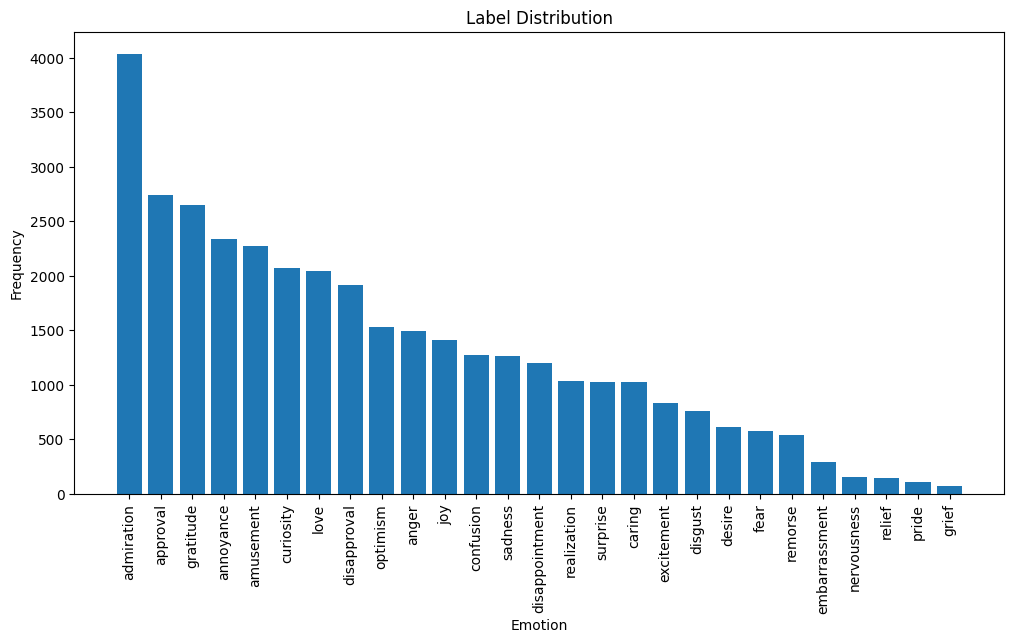

In [13]:
plt.figure(figsize=(12,6))
plt.bar(label_df["Emotion"], label_df["Count"])
plt.xticks(rotation=90)

plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.title("Label Distribution")

plt.show()

# Preprocessing (BoW for manual DT and TF-IDF for Sklearn's)

Label Pre-processing

In [14]:
df_train['single_label'] = df_train['labels'].apply(lambda x: x[0])

Text Pre-processing (Tokenize, Vectorize)

In [15]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
# Vì stop_words có các từ mang tính phủ định, nên cần giữ lại các từ đó
negations = {
    "no", "nor", "not", "don't", "didn't", "won't","isn't",
    "aren't", "wasn't", "weren't", "haven't", "hasn't", "hadn't",
    "wouldn't", "couldn't", "shouldn't"
}

stop_words = stop_words - negations

In [17]:
def text_split(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s']", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return words

df_train["tokens"] = df_train["text"].apply(text_split)

In [18]:
counter = Counter()
max_vocab = 10000

# Bag of Words (BoW)
vocab = {}

for t in df_train["tokens"]:
    counter.update(t)
    

for i, (word, freq) in enumerate(counter.most_common(max_vocab)):
    vocab[word] = i

In [19]:
def vectorize(tokens, vocab):
    vec = np.zeros(len(vocab), dtype=np.uint8)
    
    for w in tokens:
        if w in vocab:
            vec[vocab[w]] = 1
            
    return vec

In [20]:
X = np.array([vectorize(tokens, vocab) for tokens in df_train["tokens"]])
y = df_train['single_label'].values

In [21]:
vectorizer = TfidfVectorizer(max_features=10000, stop_words=list(stop_words), lowercase=True, ngram_range=(1,2), min_df=2)

In [22]:
X_train_vec=vectorizer.fit_transform(df_train["text"])
X_val_vec=vectorizer.transform(df_val["text"])
X_test_vec=vectorizer.transform(df_test["text"])

In [23]:
X.shape

(43410, 10000)

Validation Pre-processing

In [24]:
df_val["single_label"] = df_val["labels"].apply(lambda x: x[0])

In [25]:
df_val["tokens"] = df_val["text"].apply(text_split)
X_val = np.array([vectorize(tokens, vocab) for tokens in df_val["tokens"]])
y_val = df_val["single_label"].values

Test Pre-processing

In [26]:
df_test["tokens"] = df_test["text"].apply(text_split)
X_test = np.array([vectorize(tokens, vocab) for tokens in df_test["tokens"]])
y_test = df_test["labels"]

# Adjustment Functions

In [27]:
def relaxed_adjust(true_label, pred_label):
    adjusted_true = []
    for true_labels, pred in zip(true_label, pred_label):
        if pred in true_labels:
            adjusted_true.append(pred)
        else:
            adjusted_true.append(true_labels[0])
    return np.array(adjusted_true)

In [28]:
def binary_labels(y):
    binary = []
    for labels in y:
        multi_hot = [0]*(len(label_columns))
        if isinstance(labels, (int, np.integer)):
            multi_hot[labels] = 1
        else:
            for label in labels:
                multi_hot[label] = 1
        binary.append(multi_hot)
    return np.array(binary)

In [29]:
def results_display(true_labels, predicted_labels):
    adj_true = relaxed_adjust(true_labels, predicted_labels)
    true_bin = binary_labels(true_labels)
    pred_bin = binary_labels(predicted_labels)

    acc = np.mean(adj_true == predicted_labels)
    print(f"Relaxed Accuracy: {acc}")

    relaxed_f1 = f1_score(adj_true, predicted_labels, average="macro")
    print(f"Relaxed F1 Score: {relaxed_f1}")

    org_f1 = f1_score(true_bin, pred_bin, average="macro")
    print(f"F1 Score: {org_f1}")

    print(classification_report(adj_true, predicted_labels, zero_division = 0, target_names = label_columns, labels=np.arange(len(label_columns))))
    
    mcm = multilabel_confusion_matrix(true_bin, pred_bin)
    mcm_list = [1, 2, 18, 25, 27] # amusement, anger, love, sadness, neutral
    for i in mcm_list:
        disp = ConfusionMatrixDisplay(confusion_matrix=mcm[i])
        disp.plot(cmap="Blues")
        plt.title(label_columns[i])
        plt.show()

    return {"Relaxed Accuracy": acc, "Relaxed Macro F1": relaxed_f1, "Multilabel Macro F1": org_f1}

# Decision Tree - Gini (manual)

In [30]:
class Node:
    def __init__(self, feature = None, left = None, right = None, value = None):
        self.feature = feature
        self.left = left
        self.right = right
        self.value = value

In [31]:
class ManualDecisionTree:
    def __init__(self, max_depth=10, min_sample_split=5):
        self.max_depth = max_depth
        self.min_sample_split = min_sample_split

        self.tree = None
        
    def gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        impurity = 1.0
        
        for c in counts:
            p = c / len(y)
            impurity -= p ** 2
        return impurity

    def split(self, X, y, feature):
        left = X[:, feature] == 0
        right = X[:, feature] == 1
        
        return (X[left], y[left], X[right], y[right])

    def split_gini(self, X, y, feature):
        X_left, y_left, X_right, y_right = self.split(X, y, feature)
        n = len(y)
        
        if len(y_left) == 0 or len(y_right) == 0:
            return 999
        
        g_left = self.gini(y_left)
        g_right = self.gini(y_right)
        
        weighted = len(y_left)/n * g_left + len(y_right) / n * g_right
        
        return weighted

    def best_split(self, X, y):
        best_feature = None
        best_gini = 999
        
        n_features = X.shape[1]
        
        for f in range(n_features):
            g = self.split_gini(X, y, f)
            
            if g < best_gini:
                best_gini = g
                best_feature = f
        return best_feature
    
    def build_tree(self, X, y, depth, max_depth):
        if len(np.unique(y)) == 1:
            return Node(value=y[0])
        
        if depth >= max_depth:
            maj = np.bincount(y).argmax()
            return Node(value=maj)
        
        if len(y) < self.min_sample_split:
            majority = np.bincount(y).argmax()
            return Node(value=majority)
        
        feature = self.best_split(X,y)
        X_left, y_left, X_right, y_right = self.split(X,y,feature)
        
        if len(y_left) == 0 or len(y_right) == 0:
            maj = np.bincount(y).argmax()
            return Node(value=maj)
        
        l_child = self.build_tree(X_left, y_left, depth= depth + 1, max_depth= max_depth)
        r_child = self.build_tree(X_right, y_right, depth= depth + 1, max_depth= max_depth)
        
        return Node(feature=feature, left=l_child, right=r_child)
    
    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0, self.max_depth)

    def predict_one(self, node, x):
        if node.value is not None:
            return node.value
        
        if x[node.feature] == 0:
            return self.predict_one(node.left, x)
        else:
            return self.predict_one(node.right, x)
        
    def predict(self, X):
        predictions = []
        
        for x in X:
            pred = self.predict_one(self.tree, x)
            predictions.append(pred)
        return np.array(predictions)

Build and Validate Tree

In [32]:
# Validate using F1-Score
depths = [3,4,5,8,10,15,20,25,30]

best_depth = 0
best_f1 = 0

# Manual trees takes forever to fit 40k ish train data, so take a chunk (1000/43k)
X_small = X[:1000]
y_small = y[:1000]

for d in depths:
    print(f"Building tree with depth {d}")
    tree = ManualDecisionTree(max_depth = d, min_sample_split=5)
    tree.fit(X_small, y_small)
    y_pred_val = tree.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_depth = d
    print(f"F1 score: {f1}")
print("Best depth: ", best_depth)

Building tree with depth 3
F1 score: 0.0654536929837874
Building tree with depth 4
F1 score: 0.08823204672985314
Building tree with depth 5
F1 score: 0.1049448311147948
Building tree with depth 8
F1 score: 0.12327278850472435
Building tree with depth 10
F1 score: 0.13139703640197034
Building tree with depth 15
F1 score: 0.16546426823602028
Building tree with depth 20
F1 score: 0.17556719954356062
Building tree with depth 25
F1 score: 0.18348193429110995
Building tree with depth 30
F1 score: 0.1901525267282773
Best depth:  30


Rebuild and test 

In [33]:
best_man_DT = ManualDecisionTree(max_depth=best_depth)
best_man_DT.fit(X_small, y_small)
y_pred_test = best_man_DT.predict(X_test)

Results

Relaxed Accuracy: 0.476506357103372
Relaxed F1 Score: 0.2154968014083669
F1 Score: 0.19373100552036202
                precision    recall  f1-score   support

    admiration       0.40      0.28      0.33       448
     amusement       0.73      0.67      0.70       249
         anger       0.47      0.23      0.31       187
     annoyance       0.09      0.02      0.03       262
      approval       0.24      0.07      0.11       286
        caring       0.14      0.02      0.03       104
     confusion       0.00      0.00      0.00       127
     curiosity       0.45      0.02      0.05       208
        desire       0.00      0.00      0.00        68
disappointment       0.09      0.01      0.02       114
   disapproval       0.20      0.05      0.08       209
       disgust       0.13      0.02      0.04        83
 embarrassment       0.00      0.00      0.00        27
    excitement       0.77      0.23      0.36        73
          fear       0.33      0.01      0.03        71


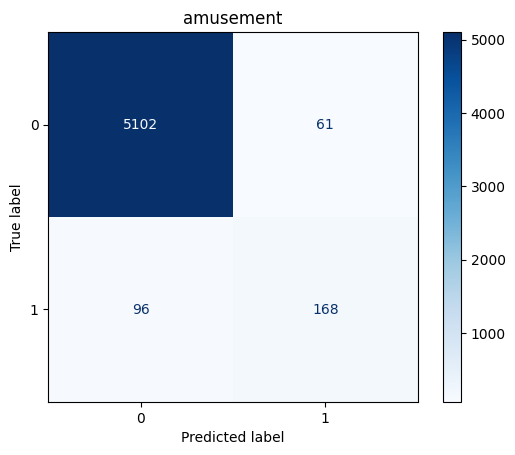

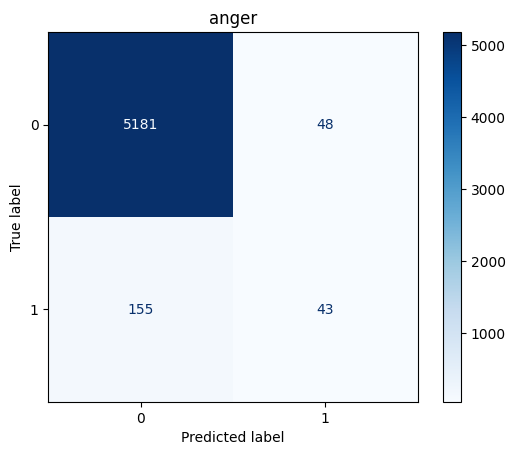

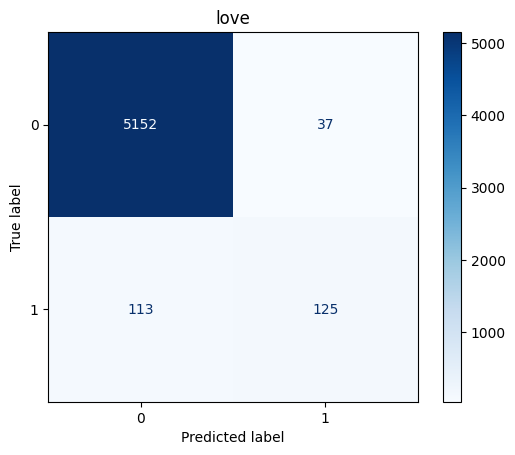

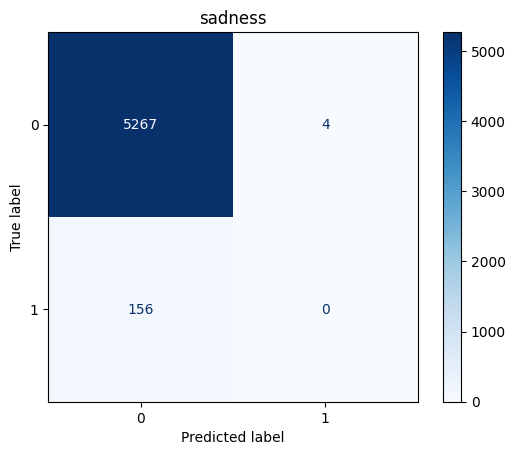

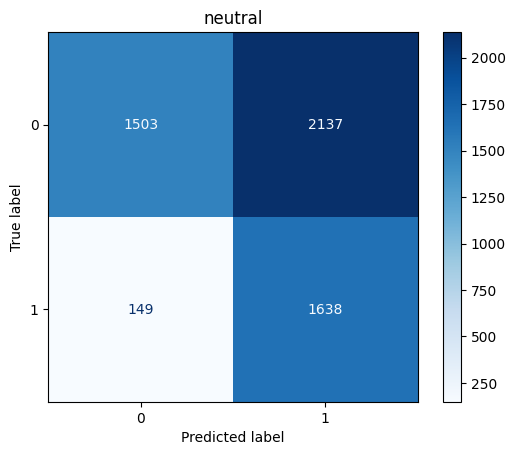

In [34]:
DT_manual_metrics = results_display(y_test, y_pred_test)

# Decision Tree - Gini (Sklearn)

Fit and Validate

In [35]:
best_f1 = -1
best_depth = 0

for depth in range(5,61,5):
    print(f"Training with depth {depth}")
    tree = DecisionTreeClassifier(criterion="gini", max_depth=depth, random_state=42)
    tree.fit(X_train_vec, y)
    y_pred_val = tree.predict(X_val_vec)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_depth = depth
    print(f"F1 score: {f1}")
print("Best depth:", best_depth)

Training with depth 5
F1 score: 0.09832699902513954
Training with depth 10
F1 score: 0.14995673566871653
Training with depth 15
F1 score: 0.1901298783073943
Training with depth 20
F1 score: 0.2182014783465537
Training with depth 25
F1 score: 0.23771571726991825
Training with depth 30
F1 score: 0.24256900097817832
Training with depth 35
F1 score: 0.25631237113594346
Training with depth 40
F1 score: 0.25830887805360486
Training with depth 45
F1 score: 0.26859802593574816
Training with depth 50
F1 score: 0.27575959761819535
Training with depth 55
F1 score: 0.2728365543771124
Training with depth 60
F1 score: 0.27408892406369956
Best depth: 50


Final build and test

In [36]:
best_sk_DT = DecisionTreeClassifier(criterion="gini", max_depth=best_depth, random_state=42)
best_sk_DT.fit(X_train_vec,y)
y_pred_test = best_sk_DT.predict(X_test_vec)

Results

Relaxed Accuracy: 0.5222037958356366
Relaxed F1 Score: 0.2942434466751592
F1 Score: 0.26029982755604136
                precision    recall  f1-score   support

    admiration       0.58      0.53      0.56       467
     amusement       0.75      0.72      0.74       247
         anger       0.51      0.24      0.32       185
     annoyance       0.41      0.04      0.08       258
      approval       0.41      0.10      0.16       286
        caring       0.14      0.03      0.05       105
     confusion       0.57      0.13      0.22       127
     curiosity       0.31      0.02      0.05       203
        desire       0.42      0.19      0.27        67
disappointment       0.00      0.00      0.00       111
   disapproval       0.13      0.01      0.02       206
       disgust       0.61      0.29      0.39        87
 embarrassment       0.00      0.00      0.00        27
    excitement       0.42      0.29      0.34        77
          fear       0.59      0.18      0.28        72

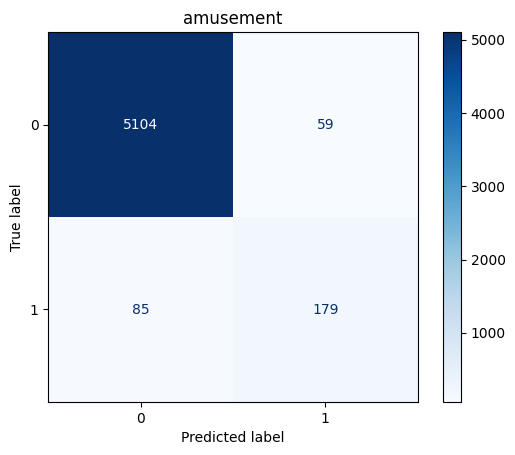

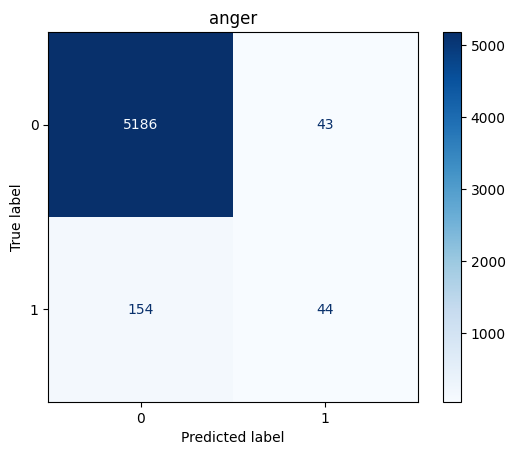

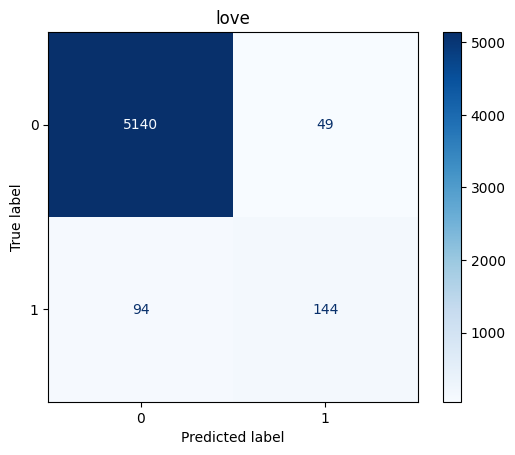

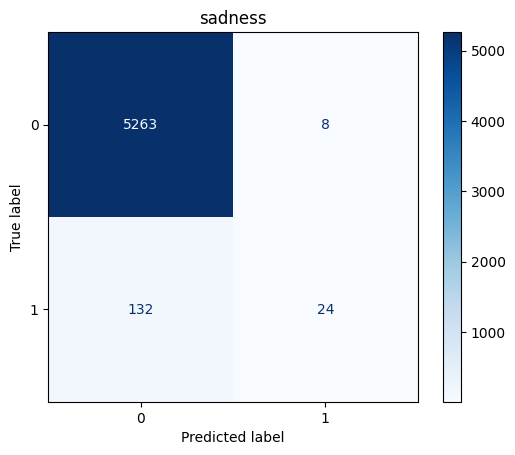

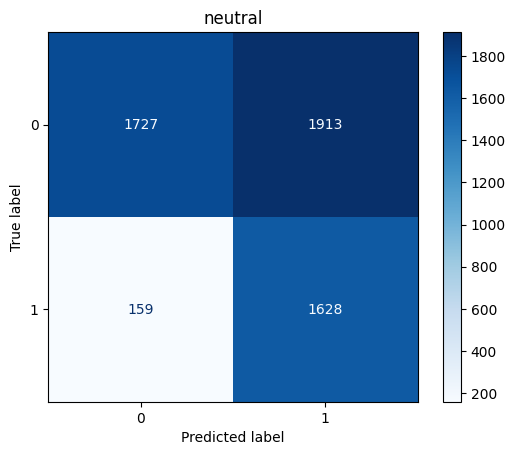

In [37]:
DT_sklearn_metrics = results_display(y_test, y_pred_test)

# Logistic Regression (Sklearn)

Fit and Validate

In [38]:
best_c = None
best_f1 = -1

for c in [0.01, 0.05, 0.1, 0.5, 1, 5, 10]:
    print(f"Training with C = {c}")
    model = LogisticRegression(C=c,max_iter=1000)
    model.fit(X_train_vec, y)
    y_pred_val = model.predict(X_val_vec)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_c = c
    print(f"F1 score: {f1}")
print("Best c:", best_c)

Training with C = 0.01
F1 score: 0.0283427608209865
Training with C = 0.05
F1 score: 0.10322633989198686
Training with C = 0.1
F1 score: 0.16677946874869007
Training with C = 0.5
F1 score: 0.2957953559651164
Training with C = 1
F1 score: 0.3216597730270711
Training with C = 5
F1 score: 0.34410014553888896
Training with C = 10
F1 score: 0.3314144051157763
Best c: 5


Predict on test data

In [39]:
best_LR = LogisticRegression(C=best_c, max_iter=1000)
best_LR.fit(X_train_vec, y)
y_pred_test = best_LR.predict(X_test_vec)

Results

Relaxed Accuracy: 0.5443154597383453
Relaxed F1 Score: 0.41056242158788453
F1 Score: 0.35825795762051993
                precision    recall  f1-score   support

    admiration       0.59      0.65      0.62       461
     amusement       0.78      0.75      0.77       243
         anger       0.42      0.31      0.36       178
     annoyance       0.33      0.21      0.26       272
      approval       0.30      0.21      0.25       292
        caring       0.28      0.19      0.23       108
     confusion       0.36      0.20      0.26       127
     curiosity       0.26      0.10      0.14       205
        desire       0.63      0.29      0.40        65
disappointment       0.38      0.13      0.19       115
   disapproval       0.36      0.18      0.24       213
       disgust       0.69      0.40      0.51        87
 embarrassment       0.56      0.19      0.29        26
    excitement       0.42      0.29      0.34        73
          fear       0.78      0.48      0.59        7

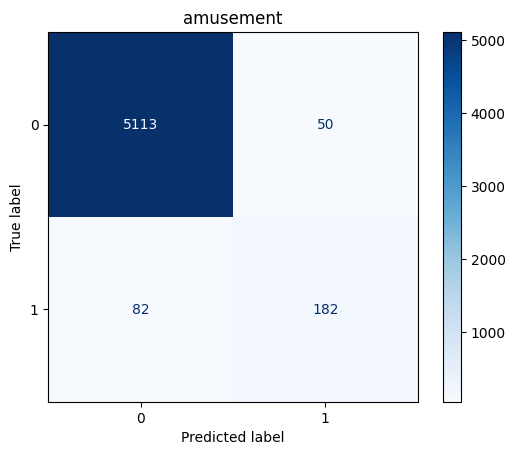

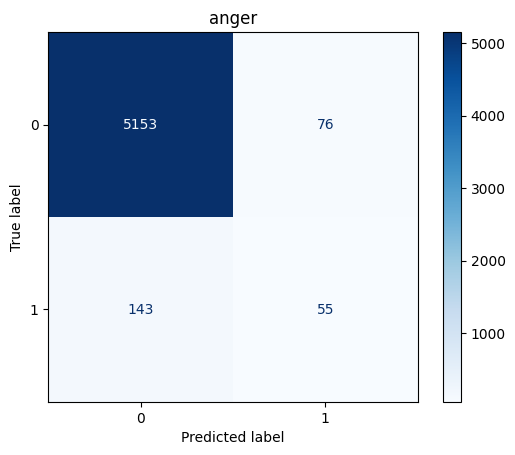

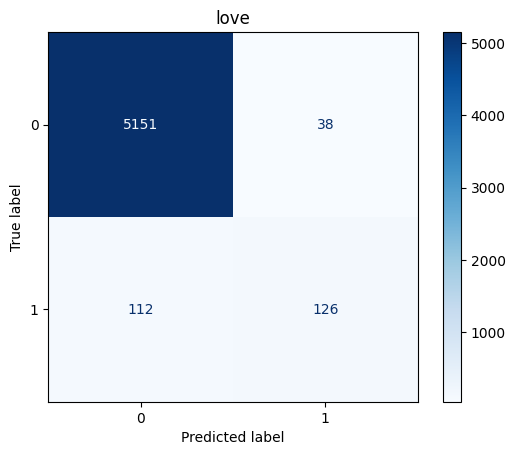

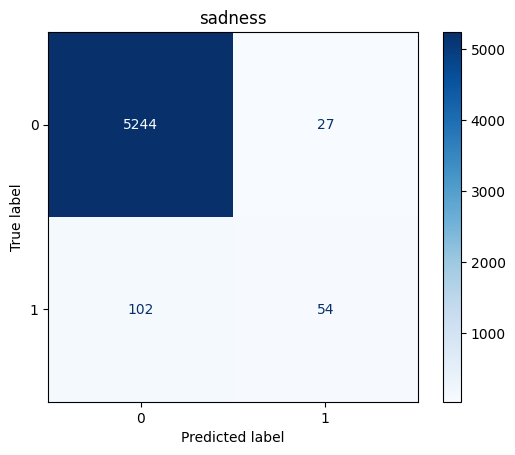

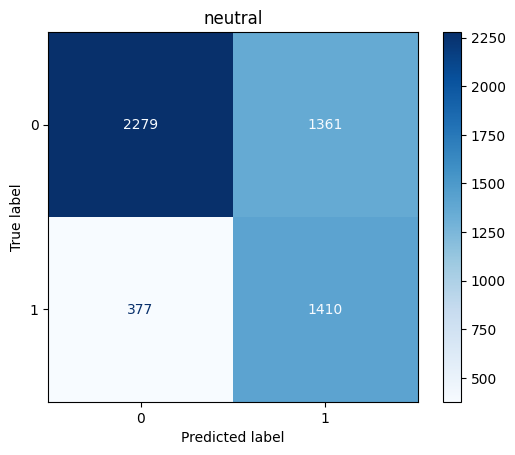

In [40]:
LR_sklearn_metrics = results_display(y_test, y_pred_test)

# Naive Bayes - Bernoulli (Sklearn)

Fit and Validate

In [41]:
best_alpha = None
best_f1 = -1

for alpha in [0.1, 0.5, 1.0, 2.0]:
    print(f"Training model with alpha = {alpha}")
    model = BernoulliNB(alpha=alpha)
    model.fit(X, y)
    y_pred_val = model.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average="macro")
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha
    print(f"F1 score: {f1}")
print("Best alpha:", best_alpha)

Training model with alpha = 0.1
F1 score: 0.2588083685390723
Training model with alpha = 0.5
F1 score: 0.17972570603894475
Training model with alpha = 1.0
F1 score: 0.1088105416096
Training model with alpha = 2.0
F1 score: 0.050104227289463135
Best alpha: 0.1


Predict on test data

In [42]:
best_Ber = BernoulliNB(alpha=best_alpha)
best_Ber.fit(X_train_vec, y)
y_pred_test = best_Ber.predict(X_test_vec)

Results

Relaxed Accuracy: 0.46876727473742397
Relaxed F1 Score: 0.2909315949757872
F1 Score: 0.2589829938858551
                precision    recall  f1-score   support

    admiration       0.51      0.55      0.53       467
     amusement       0.62      0.52      0.57       240
         anger       0.37      0.29      0.33       181
     annoyance       0.26      0.17      0.21       273
      approval       0.25      0.19      0.22       285
        caring       0.17      0.18      0.17       110
     confusion       0.23      0.17      0.20       127
     curiosity       0.18      0.11      0.14       210
        desire       0.30      0.15      0.20        68
disappointment       0.24      0.13      0.17       119
   disapproval       0.27      0.21      0.23       217
       disgust       0.48      0.34      0.40        87
 embarrassment       0.00      0.00      0.00        29
    excitement       0.32      0.32      0.32        76
          fear       0.64      0.20      0.30        71

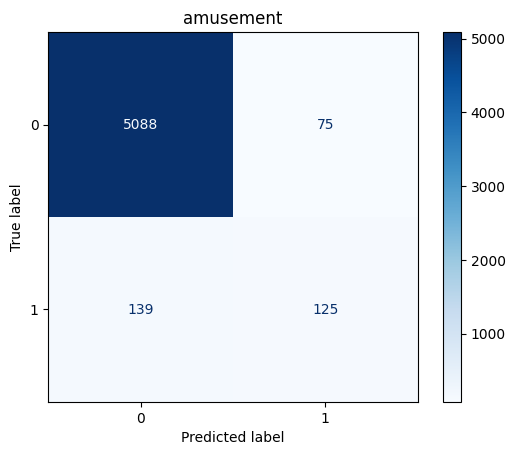

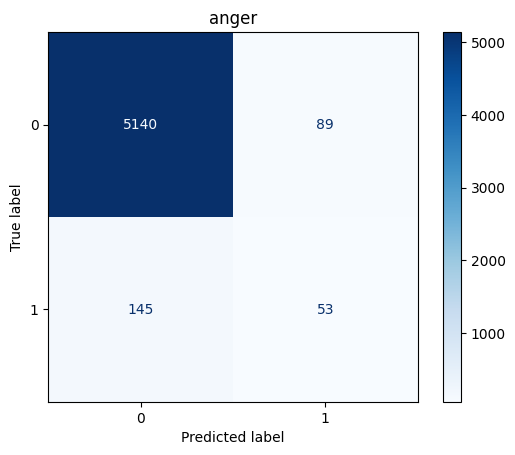

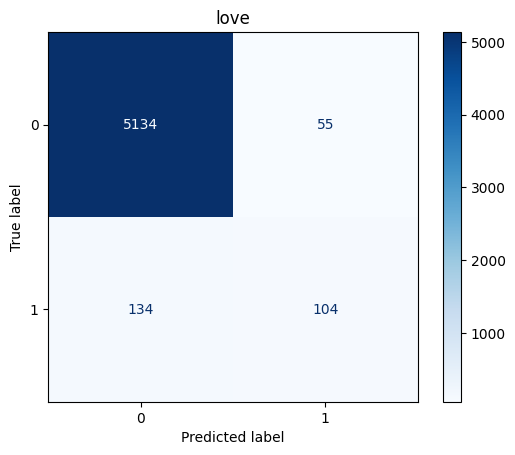

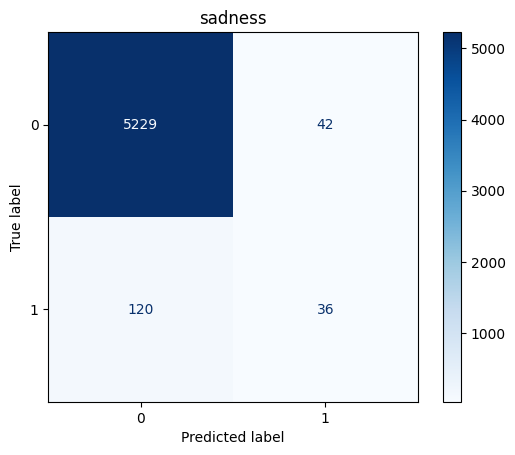

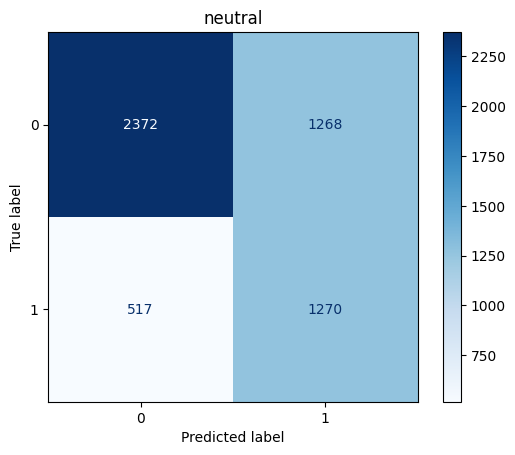

In [43]:
BerNB_sklearn_metrics = results_display(y_test, y_pred_test)

# Naive Bayes - Binomial (Sklearn)

Fit and Validate

In [44]:
best_alpha = None
best_f1 = -1

for alpha in [0.1, 0.5, 1.0, 2.0]:
    print(f"Training model with alpha = {alpha}")
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_vec, y)
    y_pred_val = model.predict(X_val_vec)
    f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha
    print(f"F1 score: {f1}")
print("Best alpha:", best_alpha)

Training model with alpha = 0.1
F1 score: 0.19841028258638027
Training model with alpha = 0.5
F1 score: 0.14220928157927024
Training model with alpha = 1.0
F1 score: 0.10702079706515773
Training model with alpha = 2.0
F1 score: 0.07182325606202286
Best alpha: 0.1


Predict on test data

In [45]:
best_Mul = MultinomialNB(alpha=best_alpha)
best_Mul.fit(X_train_vec, y)
y_pred_test = best_Mul.predict(X_test_vec)

Results

Relaxed Accuracy: 0.4564215957250783
Relaxed F1 Score: 0.21681053030381747
F1 Score: 0.187329369862992
                precision    recall  f1-score   support

    admiration       0.52      0.50      0.51       475
     amusement       0.70      0.34      0.46       240
         anger       0.52      0.16      0.25       183
     annoyance       0.25      0.08      0.12       265
      approval       0.34      0.11      0.17       290
        caring       0.32      0.13      0.18       109
     confusion       0.33      0.07      0.11       130
     curiosity       0.29      0.03      0.06       205
        desire       0.62      0.07      0.13        70
disappointment       0.30      0.03      0.05       117
   disapproval       0.31      0.05      0.09       211
       disgust       0.85      0.20      0.32        87
 embarrassment       0.00      0.00      0.00        28
    excitement       0.35      0.10      0.16        77
          fear       0.88      0.10      0.18        71


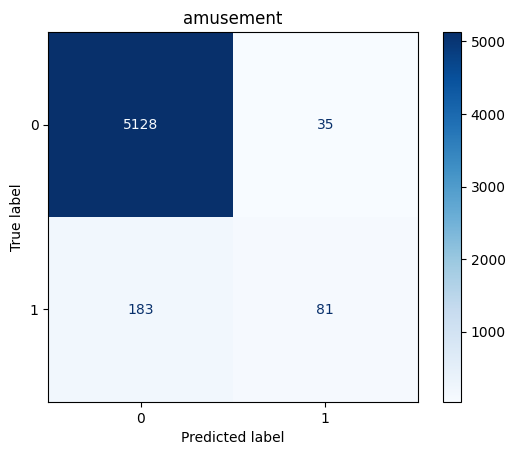

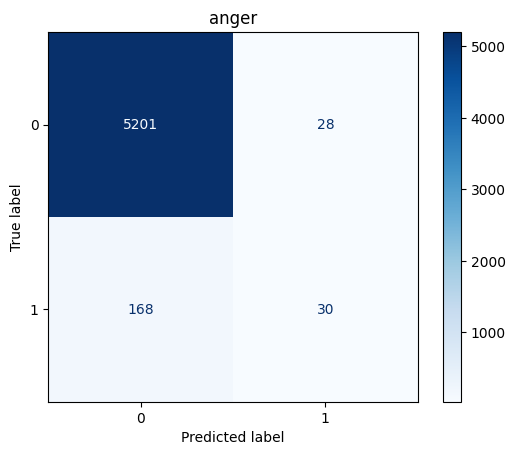

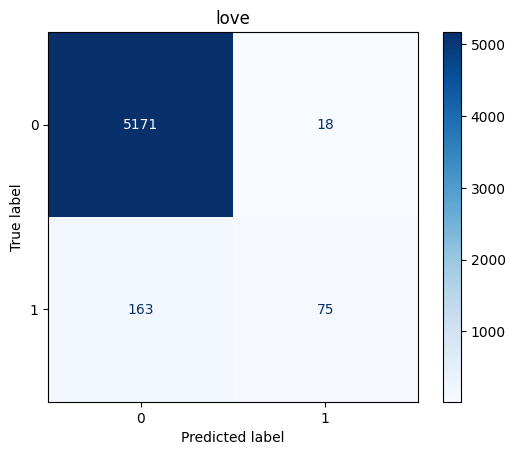

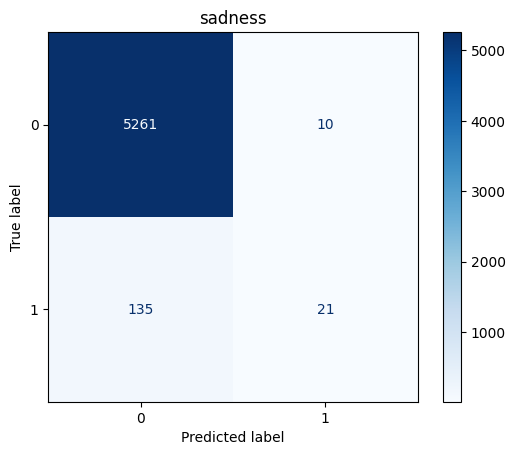

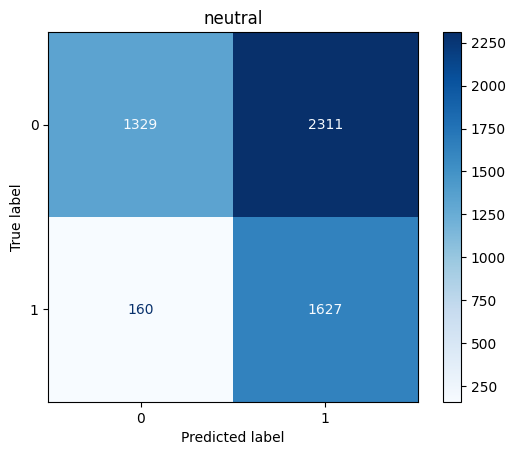

In [46]:
MulNB_sklearn_metrics = results_display(y_test, y_pred_test)

# Random Forest (Sklearn)

Fit and Validate

In [47]:
best_RF = None
best_f1 = -1
best_params = None

for depth in [5, 10, 15, 20, 25]:
    for tree in [25, 50, 75, 100]:
        print(f"Training with depth {depth}, tree count {tree}")
        model = RandomForestClassifier(n_estimators = tree, max_depth = depth, n_jobs = -1, random_state = 42)
        model.fit(X_train_vec,y)
        y_pred_val = model.predict(X_val_vec)
        f1 = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
        if f1 > best_f1:
            best_RF = model
            best_f1 = f1
            best_params = (depth, tree)
        print(f"F1 score: {f1}")
print(f"Best RF: {best_RF}")
print(f"Best parameters: {best_params}")

Training with depth 5, tree count 25
F1 score: 0.016203232504172944
Training with depth 5, tree count 50
F1 score: 0.016203232504172944
Training with depth 5, tree count 75
F1 score: 0.016203232504172944
Training with depth 5, tree count 100
F1 score: 0.016203232504172944
Training with depth 10, tree count 25
F1 score: 0.016646589014645247
Training with depth 10, tree count 50
F1 score: 0.01674140028019143
Training with depth 10, tree count 75
F1 score: 0.01649939663110724
Training with depth 10, tree count 100
F1 score: 0.01649939663110724
Training with depth 15, tree count 25
F1 score: 0.01924540738353416
Training with depth 15, tree count 50
F1 score: 0.019247274654793266
Training with depth 15, tree count 75
F1 score: 0.018047787722901464
Training with depth 15, tree count 100
F1 score: 0.018051495143248695
Training with depth 20, tree count 25
F1 score: 0.03489616856986346
Training with depth 20, tree count 50
F1 score: 0.03961460345052946
Training with depth 20, tree count 75
F1 

Predict on test data

In [48]:
y_pred_test = best_RF.predict(X_test_vec)

Results

Relaxed Accuracy: 0.3843744241754192
Relaxed F1 Score: 0.06471564302687431
F1 Score: 0.06105012267531031
                precision    recall  f1-score   support

    admiration       0.78      0.27      0.40       481
     amusement       0.87      0.05      0.10       240
         anger       0.00      0.00      0.00       189
     annoyance       0.00      0.00      0.00       260
      approval       0.00      0.00      0.00       289
        caring       0.00      0.00      0.00       109
     confusion       0.00      0.00      0.00       128
     curiosity       0.00      0.00      0.00       209
        desire       0.00      0.00      0.00        72
disappointment       0.00      0.00      0.00       117
   disapproval       0.00      0.00      0.00       210
       disgust       0.00      0.00      0.00        83
 embarrassment       0.00      0.00      0.00        28
    excitement       0.60      0.04      0.07        75
          fear       0.00      0.00      0.00        7

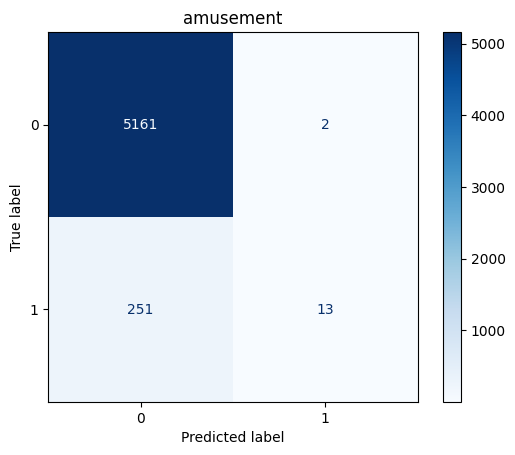

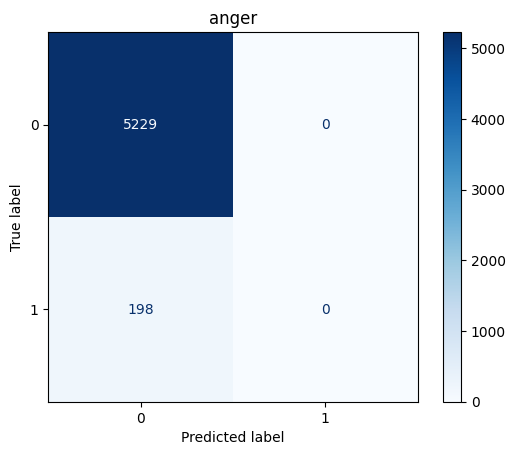

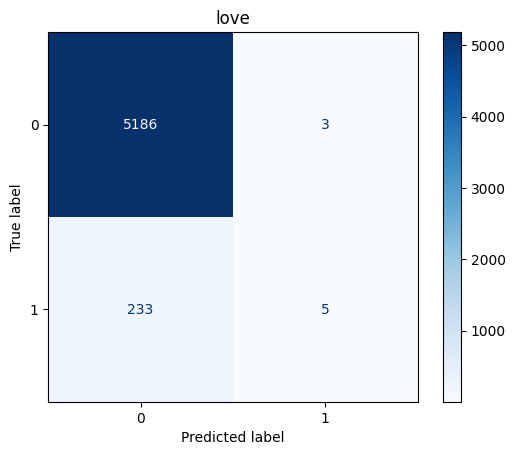

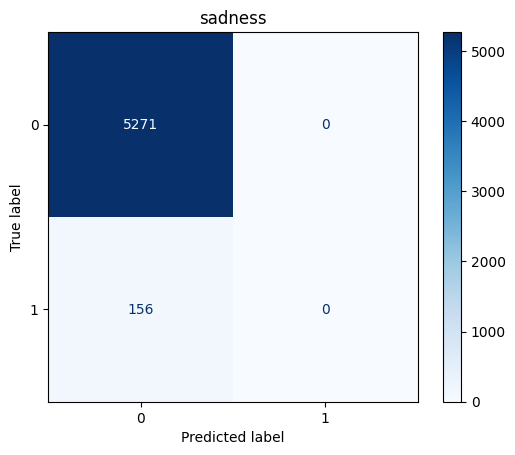

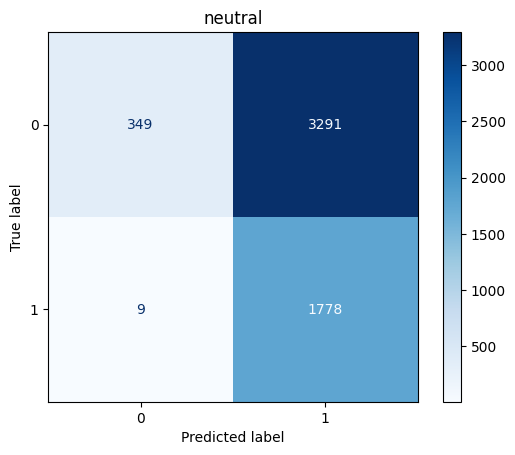

In [49]:
RF_sklearn_metrics = results_display(y_test, y_pred_test)

# Model comparison

In [50]:
comparison = {"Manual DT": DT_manual_metrics, "Sklearn DT": DT_sklearn_metrics, "Sklearn LR": LR_sklearn_metrics, "Sklearn Bernoulli NB": BerNB_sklearn_metrics, "Sklearn Multinomial NB": MulNB_sklearn_metrics, "Sklearn Random Forest": RF_sklearn_metrics}

In [51]:
comparison_df = pd.DataFrame(comparison).T
comparison_df

,Relaxed Accuracy,Relaxed Macro F1,Multilabel Macro F1
Manual DT,0.476506,0.215497,0.193731
Sklearn DT,0.522204,0.294243,0.260300
Sklearn LR,0.544315,0.410562,0.358258
Sklearn Bernoulli NB,0.468767,0.290932,0.258983
Sklearn Multinomial NB,0.456422,0.216811,0.187329
Sklearn Random Forest,0.384374,0.064716,0.061050


# Model outputs

In [52]:
import joblib
joblib.dump(best_man_DT, "s_man_dt.pkl")
joblib.dump(best_sk_DT, "s_sk_dt.pkl")
joblib.dump(best_LR, "s_lr.pkl")
joblib.dump(best_Ber, "s_ber.pkl")
joblib.dump(best_Mul, "s_mul.pkl")
joblib.dump(best_RF, "s_rf.pkl")
joblib.dump(vocab, "vocab.pkl")

['vocab.pkl']